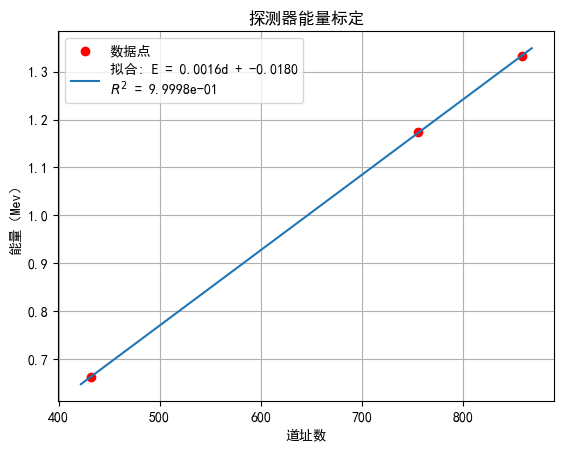

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置matplotlib支持中文的字体，这里使用的是SimHei字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像时负号'-'显示为方块的问题

# 定义两个点
x = np.array([432, 858, 755])
y = np.array([0.662, 1.332, 1.173])

# 使用numpy的polyfit进行线性拟合，1表示拟合的多项式次数为1（线性）
coefficients = np.polyfit(x, y, 1)

# 生成拟合的直线的函数
polynomial = np.poly1d(coefficients)

# 生成x的值，用于绘制直线
x_axis = np.linspace(min(x) - 10, max(x) + 10, 100)
y_axis = polynomial(x_axis)

# 计算相关系数矩阵
correlation_matrix = np.corrcoef(x, y)

# 获取相关系数（R）
correlation_xy = correlation_matrix[0,1]

# 计算决定系数（R²）
r_squared = correlation_xy**2

# 绘制原始点
plt.scatter(x, y, color='red', label='数据点')

# 绘制拟合的直线
line_label = f'拟合: E = {coefficients[0]:.4f}d + {coefficients[1]:.4f}\n$R^2$ = {r_squared:.4e}'
plt.plot(x_axis, y_axis, label=line_label)

# 添加图例
plt.legend()

# 添加标题和标签
plt.title('探测器能量标定')
plt.xlabel('道址数')
plt.ylabel('能量（Mev）')
plt.grid()

# 显示图形
plt.show()

In [2]:
(1.8299 - 5.486) / 2.76211

-1.3236619830491905

In [3]:
0.0111 * 663.30 - 4.1106

3.2520300000000004

In [2]:
0.662 - 0.662 / (1 + 0.511 / (2 * 0.662))

0.18434986376021795

In [2]:
0.0016 * 289 - 0.0180

0.4444

In [3]:
0.0016 * 141 - 0.0180

0.20760000000000003

In [4]:
100 * (0.4444 - 0.47765) / 0.47765

-6.9611640322411805

In [5]:
100 * (0.2076 - 0.18345) / 0.18345

13.164349959116928

In [8]:
(47.28 * 0.0015 - 0.0005) / (432 * 0.0015 - 0.0005)

0.10875675675675674

主峰位置: 432.0000
主峰值: 1305.1620
半高宽 (FWHM): 47.2794


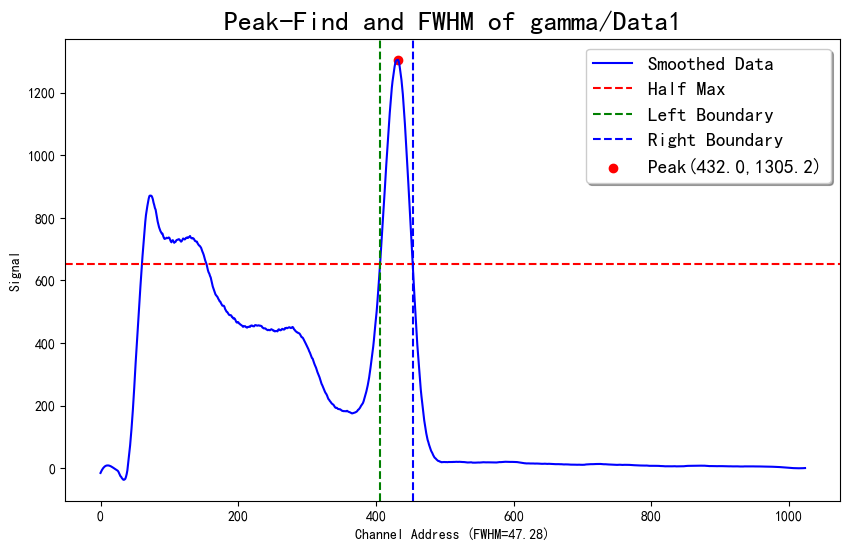

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

# AMPD算法实现
def AMPD(x, data):
    """
    实现AMPD算法  
    param x: x坐标数组，1-D numpy.ndarray  
    param data: y坐标数组，1-D numpy.ndarray  
    return: 峰值所在索引值的列表, 峰值对应的x坐标, 峰值对应的y坐标  

    参考 https://zhuanlan.zhihu.com/p/549588865
    """
    p_data = np.zeros_like(data, dtype=np.int32)
    count = data.shape[0]
    arr_rowsum = []
    for k in range(1, count // 2 + 1):
        row_sum = 0
        for i in range(k, count - k):
            if data[i] > data[i - k] and data[i] > data[i + k]:
                row_sum -= 1
        arr_rowsum.append(row_sum)
    min_index = np.argmin(arr_rowsum)
    max_window_length = min_index
    for k in range(1, max_window_length + 1):
        for i in range(k, count - k):
            if data[i] > data[i - k] and data[i] > data[i + k]:
                p_data[i] += 1

    peaks_indices = np.where(p_data == max_window_length)[0]
    peak_x = np.take(x, peaks_indices)
    peak_y = np.take(data, peaks_indices)

    return peaks_indices, peak_x, peak_y


# 数据载入
file_path = 'gamma/Data1.txt'
try:
    g_data1 = np.loadtxt(file_path)
except FileNotFoundError:
    print(f"文件 {file_path} 未找到，请检查路径")
    exit()

g_channel_address1 = np.arange(len(g_data1))

# Savitzky-Golay 滤波
window_length = 51  # 窗口长度，可以根据实际情况调整
polyorder = 3       # 多项式阶数，一般为2或3
smoothed_xg1 = savgol_filter(g_data1, window_length, polyorder)

# 主峰寻峰与计算半高宽
x = g_channel_address1
y = smoothed_xg1

# 找到主峰
peaks, _ = find_peaks(y)
peak_index = peaks[np.argmax(y[peaks])]  # 主峰索引
peak_x = x[peak_index]  # 主峰位置
peak_y = y[peak_index]  # 主峰值

# 半高宽计算
half_max = peak_y / 2
left_idx = np.where(y[:peak_index] <= half_max)[0][-1]
right_idx = np.where(y[peak_index:] <= half_max)[0][0] + peak_index
# 线性插值计算左右边界的精确位置
x_left = x[left_idx] + (half_max - y[left_idx]) / (y[left_idx + 1] - y[left_idx]) * (x[left_idx + 1] - x[left_idx])
x_right = x[right_idx] + (half_max - y[right_idx]) / (y[right_idx - 1] - y[right_idx]) * (x[right_idx - 1] - x[right_idx])
# 半高宽
fwhm = x_right - x_left

# 输出结果
print(f"主峰位置: {peak_x:.4f}")
print(f"主峰值: {peak_y:.4f}")
print(f"半高宽 (FWHM): {fwhm:.4f}")

# 可视化
colors = ['blue', 'orange', 'green', 'red', 'purple']  # 定义颜色用于可视化
plt.figure(figsize=(10, 6))
plt.plot(x, y, label="Smoothed Data", color=colors[0])
plt.axhline(half_max, color=colors[3], linestyle="--", label="Half Max")
plt.axvline(x_left, color="g", linestyle="--", label="Left Boundary")
plt.axvline(x_right, color="b", linestyle="--", label="Right Boundary")
plt.scatter([peak_x], [peak_y], color="red", label=f"Peak({peak_x:.1f},{peak_y:.1f})")
plt.legend(fontsize=14, frameon=True, shadow=True)
plt.title("Peak-Find and FWHM of gamma/Data1", fontsize=20)
plt.xlabel(f"Channel Address (FWHM={fwhm:.2f})")
plt.ylabel("Signal")
plt.show()


FileNotFoundError: alpha/Data1.txt not found.